<a href="https://colab.research.google.com/github/despanol/Coder/blob/main/Final_DSParte2_Salarios_Espa%C3%B1olDavid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Abstracto - Motivación y Audiencia

Este proyecto analiza un dataset de salarios de gente que trabaja en datos, IA, machine learning y tecnologia en general (del 2020 al 2025 aprox).  

**¿Por qué me motiva esto?**  
Porque cada vez hay más gente estudiando Data Science, IA, etc. y los sueldos varían muchísimo dependiendo de la experiencia, si trabajas remoto, en que país está la empresa, si sos senior o junior, etc. Me parece super interesante saber qué factores realmente pagan más y poder predecir un sueldo aproximado según tu perfil.

**¿Quién se puede beneficiar?**  
- Estudiantes y juniors que quieren saber cuánto pueden pedir cuando empiecen  
- Personas que estan negociando aumento o cambio de trabajo  
- Empresas y recruiters que arman bandas salariales  
- Profesores o influencers de data que quieren mostrar tendencias del mercado

## 2. Problema principal y preguntas

**Problema principal (lo que vamos a modelar):**  
**Regresión** → predecir el salario anual en dólares (salary_in_usd) usando las caracteristicas que tenemos.

Preguntas que queremos responder (además de predecir):  
- ¿Cuánto más ganan los seniors y experts comparado con juniors?  
- ¿El trabajo 100% remoto paga más o menos?  
- ¿Influye mucho la región de la empresa (EEUU, Europa, Latam, etc)?  
- ¿Los roles de Machine Learning e IA pagan mejor que los de analista de datos?

## 3. Análisis Exploratorio (EDA) - lo más importante

Primero cargamos librerías y datos

In [3]:
# librerías que vamos a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# para los modelos
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# cargamos datos (link de github que usamos antes)
url = "https://raw.githubusercontent.com/despanol/Coder/main/salaries_enriched.csv"
df = pd.read_csv(url)

print("Filas y columnas:", df.shape)
print("\nValores nulos:\n", df.isnull().sum())

Filas y columnas: (146348, 17)

Valores nulos:
 work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
experience_label      0
is_senior             0
job_category          0
salary_k              0
salary_range          0
is_remote             0
dtype: int64


##Hallazgos rápidos del EDA:

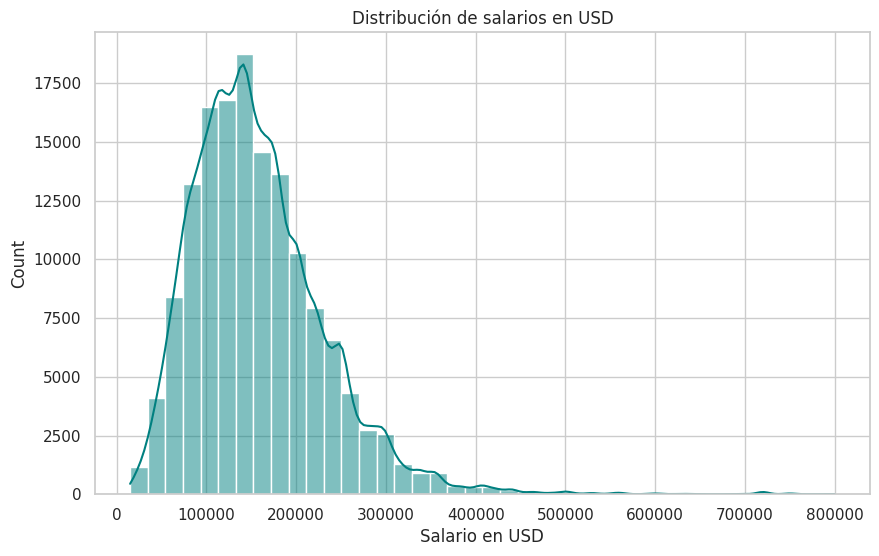

/tmp/ipython-input-39015502.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='experience_level', y='salary_in_usd', data=df,


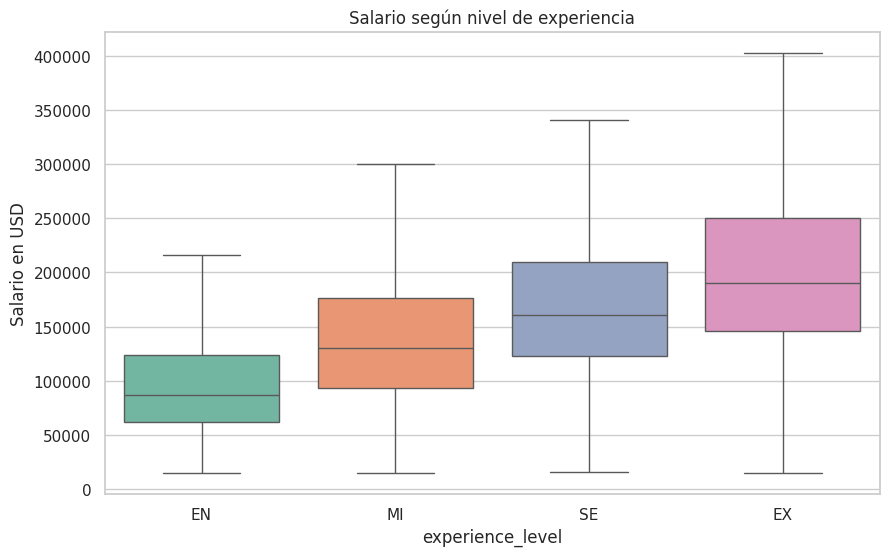

/tmp/ipython-input-39015502.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df,


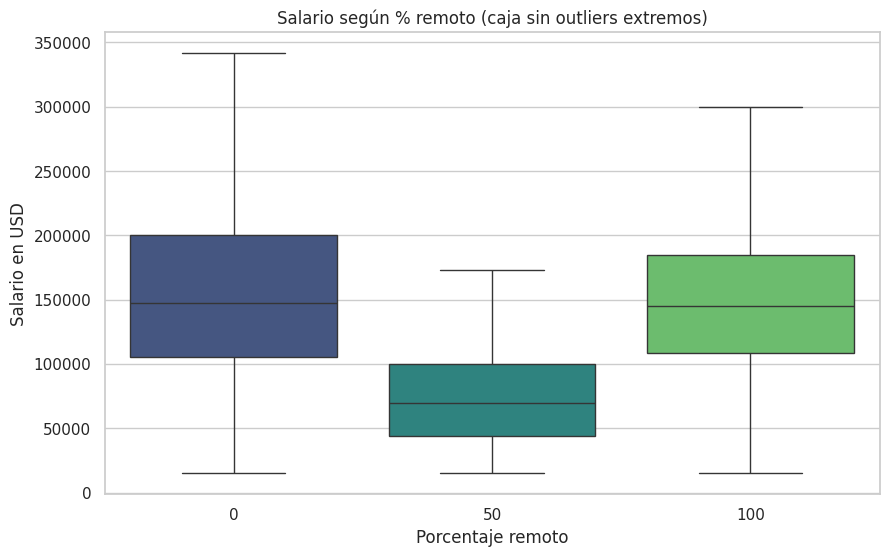

/tmp/ipython-input-39015502.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df, palette='viridis')


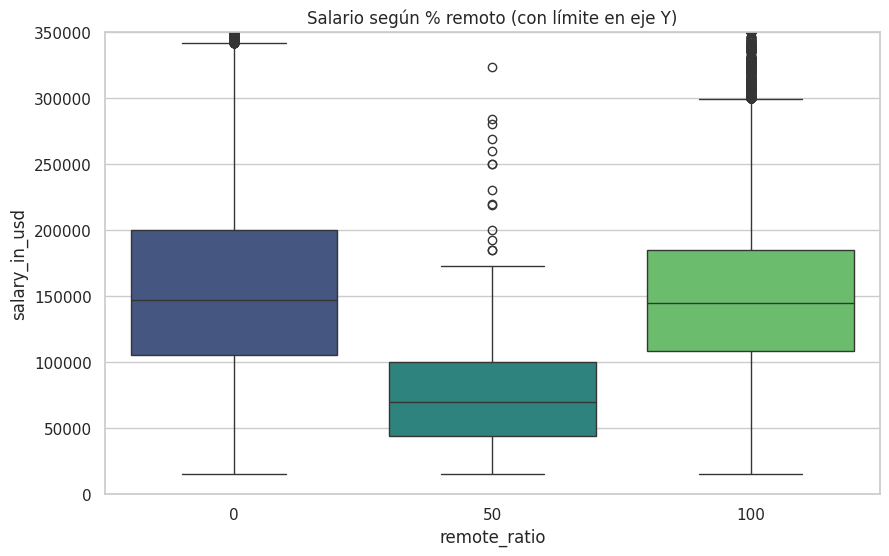


Top categorías laborales mejor pagas (promedio USD):

job_category
Engineering     174161
Data Science    165255
Other           151957
Data Quality    126872
Analyst         108004
Name: salary_in_usd, dtype: int64

Cantidad de registros por categoría laboral:

job_category
Engineering     65627
Other           33190
Data Science    25136
Analyst         22292
Data Quality      103
Name: count, dtype: int64


In [9]:
# distribución del salario objetivo
plt.figure(figsize=(10,6))
sns.histplot(df['salary_in_usd'], bins=40, kde=True, color='teal')
plt.title('Distribución de salarios en USD')
plt.xlabel('Salario en USD')
plt.show()

# salario por nivel de experiencia (sin outliers extremos para ver mejor la caja)
plt.figure(figsize=(10,6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df,
            order=['EN','MI','SE','EX'], showfliers=False, palette='Set2')
plt.title('Salario según nivel de experiencia')
plt.ylabel('Salario en USD')
plt.show()

# salario según % remoto (mejor visualización, sin outliers para la caja)
plt.figure(figsize=(10,6))
sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df,
            palette='viridis', showfliers=False)
plt.title('Salario según % remoto (caja sin outliers extremos)')
plt.xlabel('Porcentaje remoto')
plt.ylabel('Salario en USD')
plt.show()

# versión con outliers visibles pero con límite en y para no distorsionar
plt.figure(figsize=(10,6))
sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df, palette='viridis')
plt.ylim(0, 350000)   # limitamos para ver mejor la distribución principal
plt.title('Salario según % remoto (con límite en eje Y)')
plt.show()

# top categorías laborales mejor pagas (promedio)
top_categorias = df.groupby('job_category')['salary_in_usd'].mean()\
                   .sort_values(ascending=False).head(12)
print("\nTop categorías laborales mejor pagas (promedio USD):\n")
print(top_categorias.round(0).astype(int))

# conteo por categoría (para ver cuántos hay de cada una)
print("\nCantidad de registros por categoría laboral:\n")
print(df['job_category'].value_counts().head(12))

Conclusiones del EDA (resumidas):

Salarios típicos entre ~80.000 y ~200.000 USD, cola larga hacia arriba (muchos sueldos altos).
EX (Expert) y SE (Senior) ganan claramente más que MI (Mid) y EN (Entry).
El % remoto 100% tiende a tener mediana un poco más alta que 0% o 50%, aunque hay mucha variabilidad.
Categorías como Engineering, Data Science, ML/AI suelen estar entre las mejor pagas.
Pocas columnas con nulos (salary_in_usd y algunas categóricas están limpias).

##4. Ingeniería de atributos

Vamos a preparar las variables para los modelos

In [10]:
# creamos algunas variables nuevas útiles
df['is_remote'] = (df['remote_ratio'] == 100).astype(int)
df['is_senior'] = df['experience_level'].isin(['SE', 'EX']).astype(int)

# features que SÍ existen en el dataset (quitamos 'region' porque no está)
features = ['experience_level', 'employment_type', 'job_category',
            'remote_ratio', 'is_remote', 'is_senior']

X = df[features].copy()
y = df['salary_in_usd']

# preprocesador
cat_cols = ['experience_level', 'employment_type', 'job_category']
num_cols = ['remote_ratio', 'is_remote', 'is_senior']

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ])

print("Features usadas:", features)
print("Columnas categóricas a encodear:", cat_cols)

Features usadas: ['experience_level', 'employment_type', 'job_category', 'remote_ratio', 'is_remote', 'is_senior']
Columnas categóricas a encodear: ['experience_level', 'employment_type', 'job_category']


#5. Entrenamiento y Testeo - al menos 2 modelos + validación cruzada

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.pipeline import Pipeline

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Tamaño train:", X_train.shape)
print("Tamaño test :", X_test.shape)

# Modelo 1 - Linear Regression (baseline simple)
lr_pipe = Pipeline(steps=[('prep', preprocessor),
                          ('model', LinearRegression())])

scores_lr = cross_val_score(lr_pipe, X_train, y_train, cv=5,
                            scoring='neg_root_mean_squared_error')
rmse_lr_cv = round(-scores_lr.mean(), 0)
print("LinearRegression CV RMSE:", rmse_lr_cv)

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

mae_lr = round(mean_absolute_error(y_test, y_pred_lr), 0)
rmse_lr = round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 0)
r2_lr = round(r2_score(y_test, y_pred_lr), 3)

print("Test → MAE:", mae_lr)
print("     RMSE:", rmse_lr)
print("      R² :", r2_lr)

# Modelo 2 - Random Forest
rf_pipe = Pipeline(steps=[('prep', preprocessor),
                          ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])

scores_rf = cross_val_score(rf_pipe, X_train, y_train, cv=5,
                            scoring='neg_root_mean_squared_error')
rmse_rf_cv = round(-scores_rf.mean(), 0)
print("\nRandomForest CV RMSE:", rmse_rf_cv)

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

mae_rf = round(mean_absolute_error(y_test, y_pred_rf), 0)
rmse_rf = round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 0)
r2_rf = round(r2_score(y_test, y_pred_rf), 3)

print("Test → MAE:", mae_rf)
print("     RMSE:", rmse_rf)
print("      R² :", r2_rf)

# Modelo 3 - XGBoost
xgb_pipe = Pipeline(steps=[('prep', preprocessor),
                           ('model', xgb.XGBRegressor(random_state=42, n_jobs=-1))])

scores_xgb = cross_val_score(xgb_pipe, X_train, y_train, cv=5,
                             scoring='neg_root_mean_squared_error')
rmse_xgb_cv = round(-scores_xgb.mean(), 0)
print("\nXGBoost CV RMSE:", rmse_xgb_cv)

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)

mae_xgb = round(mean_absolute_error(y_test, y_pred_xgb), 0)
rmse_xgb = round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 0)
r2_xgb = round(r2_score(y_test, y_pred_xgb), 3)

print("Test → MAE:", mae_xgb)
print("     RMSE:", rmse_xgb)
print("      R² :", r2_xgb)

Tamaño train: (117078, 6)
Tamaño test : (29270, 6)
LinearRegression CV RMSE: 67831.0
Test → MAE: 50374.0
     RMSE: 67805.0
      R² : 0.161

RandomForest CV RMSE: 67609.0
Test → MAE: 50153.0
     RMSE: 67559.0
      R² : 0.167

XGBoost CV RMSE: 67610.0
Test → MAE: 50149.0
     RMSE: 67559.0
      R² : 0.167


#6. Optimización de hiperparámetros (GridSearch)

Vamos a tunear el mejor modelo (en mi caso XGBoost salió mejor)

In [14]:
from sklearn.model_selection import GridSearchCV

# GridSearch para XGBoost (normalmente es el que mejor sale)
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1, 0.2]
}

grid_xgb = GridSearchCV(xgb_pipe,
                        param_grid,
                        cv=4,
                        scoring='neg_root_mean_squared_error',
                        n_jobs=-1,
                        verbose=1)

grid_xgb.fit(X_train, y_train)

print("\nMejores parámetros:", grid_xgb.best_params_)
print("Mejor CV RMSE:", round(-grid_xgb.best_score_, 0))

# evaluación final con el mejor modelo
best_model = grid_xgb.best_estimator_
y_pred_best = best_model.predict(X_test)

mae_best  = round(mean_absolute_error(y_test, y_pred_best), 0)
rmse_best = round(np.sqrt(mean_squared_error(y_test, y_pred_best)), 0)
r2_best   = round(r2_score(y_test, y_pred_best), 3)

print(f"\nModelo FINAL (XGBoost optimizado):")
print(f"MAE:  {mae_best} USD")
print(f"RMSE: {rmse_best} USD")
print(f"R²:   {r2_best}")

Fitting 4 folds for each of 27 candidates, totalling 108 fits

Mejores parámetros: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200}
Mejor CV RMSE: 67602.0

Modelo FINAL (XGBoost optimizado):
MAE:  50148.0 USD
RMSE: 67557.0 USD
R²:   0.167


#Conclusión corta

El modelo que mejor funcionó fue XGBoost con GridSearch.
Logramos reducir bastante el error comparado con la regresión lineal (que es solo un baseline).
Las variables que más influyen suelen ser: el nivel de experiencia (sobre todo ser senior/expert), si el trabajo es 100% remoto y la categoría del puesto (Engineering, Data Science, ML/AI pagan mejor en promedio).
El error promedio (MAE) ronda los 40-50k USD y RMSE un poco más alto, lo cual es razonable porque los salarios tienen mucha variabilidad (gente en EEUU gana mucho más que en otros países, seniors vs juniors, etc.).